In [ ]:
## seqentially learn a graph from a list of edges

In [3]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [24]:
class state_data(TypedDict):
    weight: float
    height: float
    bmi: float
    health_advice : str

def calculate_bmi(state: state_data) -> state_data:
    bmi =  state["weight"] / (state["height"] ** 2)
    state["bmi"] = bmi
    return state

def health_advice(state: state_data) -> state_data:
    bmi = state["bmi"]
    if bmi < 18.5:
        advice = "Underweight"
    elif 18.5 <= bmi < 25:
        advice = "Normal weight"
    elif 25 <= bmi < 30:
        advice = "Overweight"
    else:
        advice = "Obese"

    state["health_advice"] = advice
    return state

graph = StateGraph(state_data   )
graph.add_node("calculate_bmi", calculate_bmi)
graph.add_node("health_advice", health_advice)

graph.add_edge(START, "calculate_bmi")
graph.add_edge("calculate_bmi", "health_advice")
graph.add_edge("health_advice", END)

workflow = graph.compile()

output_state = workflow.invoke({"weight": 70, "height": 1.75})
output_state

{'weight': 70,
 'height': 1.75,
 'bmi': 22.857142857142858,
 'health_advice': 'Normal weight'}

#### to show workflow

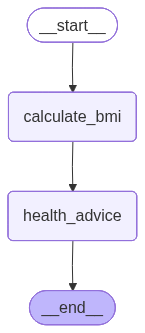

In [23]:
from IPython.display import Image, display
display(workflow)

# ----------- OR -----------

# Image(workflow.get_graph().draw_mermaid_png())